# The classical anharmonic oscillator

The `AnharmonicOscillator` class of the Models module implements the classical model of the non-linear optical response of
R. W. Boyd, *Nonlinear Optics*, 4th ed. (2020), Section 1.4. The displacement $x$ of an electron bound to a nucleus obeys

$$\ddot{x} + 2\gamma\dot{x} + \omega_0^2 x + a x^2 - b x^3 = -E(t)$$

and the polarization is $P = -Nx$, where $N$ is the density of the oscillators. The quadratic term $a$ describes a
non-centrosymmetric medium and gives the second order response, the cubic term $b$ a centrosymmetric medium and gives the third
order one. Atomic units are used ($e = m = \hbar = 1$) and $P = \chi E$.

The class provides:

* the analytical susceptibilities $\chi^{(1)}$, $\chi^{(2)}$ and $\chi^{(3)}$ (with signed frequencies);
* the numerical solution of the equation of motion (fourth order Runge-Kutta), also for many fields at the same time;
* the response to delta-shaped and sine-shaped fields, stored in the format of the `YamboNLDBParser` class, so that it can be
  analyzed with the Optics module (see the Analysis_Optics notebook).

In [1]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
from mppi.Models.AnharmonicOscillator import AnharmonicOscillator
from mppi.Optics.Utils import fit_sum_frequencies
from mppi.Utilities.Constants import HaToeV, FsToAu

print('Notebook executed on', datetime.datetime.now().strftime('%d/%m/%Y %H:%M'))

Notebook executed on 02/10/2026 11:58


## Linear susceptibility

The linear susceptibility is $\chi^{(1)}(\omega) = N/D(\omega)$ with $D(\omega) = \omega_0^2 - \omega^2 - 2i\omega\gamma$. Close to the
resonance the imaginary part is a Lorentzian with full width at half maximum $2\gamma$

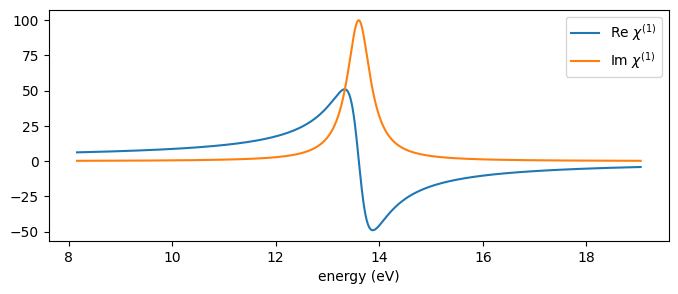

FWHM = 0.0196 Ha, 2*gamma = 0.0200 Ha


In [2]:
osc = AnharmonicOscillator(omega0=0.5, gamma=0.01) # Ha
w = np.linspace(0.3, 0.7, 1001)
chi1 = osc.chi1(w)

plt.figure(figsize=(8, 3))
plt.plot(w*HaToeV, chi1.real, label=r'Re $\chi^{(1)}$')
plt.plot(w*HaToeV, chi1.imag, label=r'Im $\chi^{(1)}$')
plt.xlabel('energy (eV)')
plt.legend()
plt.show()

half = w[chi1.imag > chi1.imag.max()/2]
print('FWHM = %.4f Ha, 2*gamma = %.4f Ha' % (half[-1]-half[0], 2*osc.gamma))

## Response to a monochromatic field

The `sine_response` method computes the polarization induced by $E_0\sin(\omega(t-t_0))$ switched on at $t_0$. After the switch on
the polarization contains a transient that oscillates at the resonance frequency and decays as $e^{-\gamma t}$: the steady state,
used to extract the susceptibilities, is reached after some multiples of $1/\gamma$ (the Optics module warns if the fit starts
before $12/\gamma$). Here the frequency of the field is detuned from the resonance, so the beating between the two components is
visible

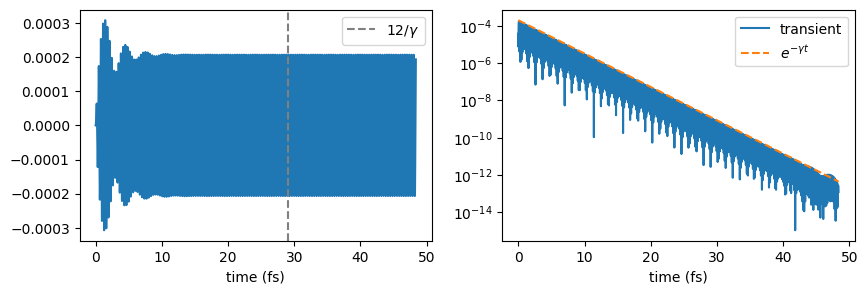

In [3]:
time = np.arange(0, 2000, 0.25) # au
data = osc.sine_response(time, [0.45], amplitude=1e-5, initial_time=0.)
pol = data.Polarization[0][0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(data.get_time(), pol)
axes[0].axvline(12/osc.gamma/FsToAu, color='gray', ls='--', label=r'$12/\gamma$')
axes[0].set_xlabel('time (fs)')
axes[0].legend()
# the steady state is P = Im[2 chi1 E(w) exp(-iwt)], with E(w) = i E0/2
steady = (2*osc.chi1(0.45)*0.5j*1e-5*np.exp(-0.45j*time)).real
axes[1].semilogy(data.get_time(), np.abs(pol-steady), label='transient')
axes[1].semilogy(data.get_time(), 1e-5*np.abs(osc.chi1(0.45))*np.exp(-osc.gamma*time), '--', label=r'$e^{-\gamma t}$')
axes[1].set_xlabel('time (fs)')
axes[1].legend()
plt.show()

## Harmonics and inversion symmetry

The spectrum of the steady state polarization shows the harmonics generated by the non-linear terms (Boyd, Fig. 1.5.2). The
non-centrosymmetric oscillator ($a \neq 0$) produces both even and odd harmonics, and a static polarization (optical rectification).
The centrosymmetric one ($b \neq 0$) produces only odd harmonics. A large field is used to make the harmonics visible

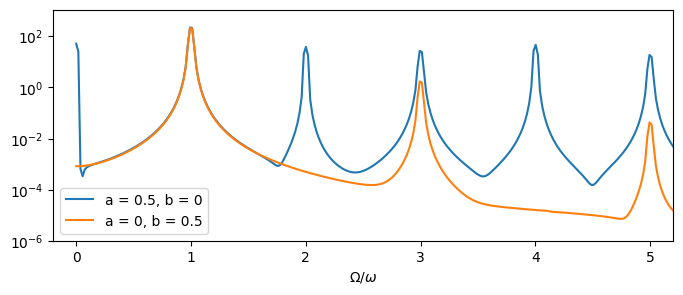

In [4]:
w0 = 0.12 # Ha, far from the resonances
time = np.arange(0, 4000, 0.25)
steady = time > 12/osc.gamma

plt.figure(figsize=(8, 3))
for o, label in [(AnharmonicOscillator(omega0=0.5, gamma=0.01, a=0.5), 'a = 0.5, b = 0'),
                 (AnharmonicOscillator(omega0=0.5, gamma=0.01, b=0.5), 'a = 0, b = 0.5')]:
    p = o.sine_response(time, [w0], amplitude=2e-2, substeps=4).Polarization[0][0][steady]
    spectrum = np.abs(np.fft.rfft(p*np.hanning(len(p))))
    freqs = 2*np.pi*np.fft.rfftfreq(len(p), d=time[1]-time[0])
    plt.semilogy(freqs/w0, spectrum, label=label)
plt.xlim(-0.2, 5.2)
plt.ylim(1e-6, None)
plt.xlabel(r'$\Omega/\omega$')
plt.legend()
plt.show()

## Perturbative regime

The amplitude of the $n$-th harmonic scales as $E_0^n$ as long as the response is perturbative. The equation of motion can be solved
for several fields at the same time with the `solve` method, which receives a function of the time that returns the field of each
run. The harmonics are obtained by fitting the steady state polarization with the `fit_sum_frequencies` function of the Optics module.
For larger fields the electron escapes from the potential well (the cubic potential has a barrier at $x = \omega_0^2/a$)

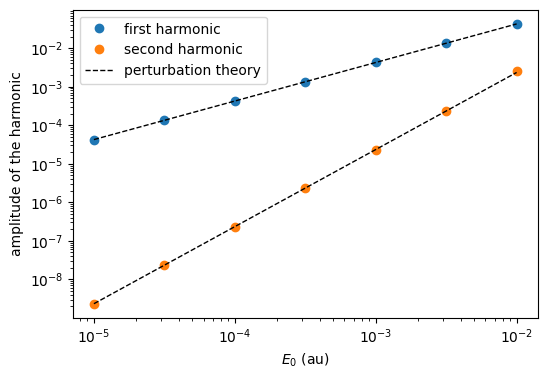

relative deviation of the second harmonic from the perturbative value:
[-0.0001 -0.     -0.      0.0001  0.0005  0.0053  0.0612]


In [5]:
osc2 = AnharmonicOscillator(omega0=0.5, gamma=0.01, a=0.5)
E0 = np.logspace(-5, -2, 7)
time = np.arange(0, 2000, 0.25)
pol = osc2.solve(time, lambda t: E0*np.sin(w0*t), substeps=4)

steady = time > 12/osc2.gamma
A = np.array([[fit_sum_frequencies(time[steady], p[steady], {1: w0, 2: 2*w0})[0][n]['A'] for n in (1, 2)] for p in pol])
# perturbative amplitudes: |P(nw)| = |chi E(w)^n| and the sine amplitude is 2|P(nw)|
A1 = 2*np.abs(osc2.chi1(w0))*E0/2
A2 = 2*np.abs(osc2.chi2(w0, w0))*(E0/2)**2

plt.figure(figsize=(6, 4))
plt.loglog(E0, A[:, 0], 'o', label='first harmonic')
plt.loglog(E0, A1, 'k--', lw=1)
plt.loglog(E0, A[:, 1], 'o', label='second harmonic')
plt.loglog(E0, A2, 'k--', lw=1, label='perturbation theory')
plt.xlabel('$E_0$ (au)')
plt.ylabel('amplitude of the harmonic')
plt.legend()
plt.show()
print('relative deviation of the second harmonic from the perturbative value:')
print(np.round(A[:, 1]/A2-1, 4))

## Non-linear susceptibilities

The second order susceptibility of the second harmonic generation (Boyd, Eq. (1.4.20))

$$\chi^{(2)}(2\omega;\omega,\omega) = \frac{Na}{D(2\omega)D(\omega)^2}$$

shows a one-photon resonance at $\omega = \omega_0$ and a two-photon resonance at $\omega = \omega_0/2$. It is proportional to the product
of three linear susceptibilities, so the ratio $\chi^{(2)}(2\omega;\omega,\omega)/[\chi^{(1)}(2\omega)\chi^{(1)}(\omega)^2] = a/N^2$ does
not depend on the frequency (Miller's rule, Boyd, Section 1.4.2)

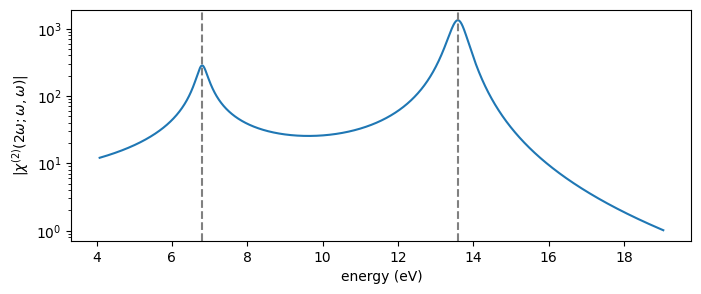

Miller ratio : min 0.100000  max 0.100000  (a/N^2 = 0.100000)


In [6]:
osc2 = AnharmonicOscillator(omega0=0.5, gamma=0.01, a=0.1)
w = np.linspace(0.15, 0.7, 2001)
chi2 = osc2.chi2(w, w)

plt.figure(figsize=(8, 3))
plt.semilogy(w*HaToeV, np.abs(chi2))
for wr in [0.25, 0.5]:
    plt.axvline(wr*HaToeV, color='gray', ls='--')
plt.xlabel('energy (eV)')
plt.ylabel(r'$|\chi^{(2)}(2\omega;\omega,\omega)|$')
plt.show()

miller = chi2/(osc2.chi1(2*w)*osc2.chi1(w)**2)
print('Miller ratio : min %.6f  max %.6f  (a/N^2 = %.6f)' % (miller.real.min(), miller.real.max(), osc2.a/osc2.density**2))

The frequencies of the susceptibilities are signed, and the negative ones correspond to the complex conjugate fields: for instance
`chi2(w1,-w2)` is the difference frequency generation $\chi^{(2)}(\omega_1-\omega_2;\omega_1,-\omega_2)$ and `chi2(w,-w)` the optical
rectification. For the centrosymmetric oscillator `chi3(w1,w2,w3)` gives $\chi^{(3)}(\omega_1+\omega_2+\omega_3;\omega_1,\omega_2,\omega_3)$.
The reality of the fields implies $\chi(-\omega_\sigma;-\omega_1,-\omega_2) = \chi(\omega_\sigma;\omega_1,\omega_2)^*$ (Boyd, Eq. (1.5.5))

In [7]:
w1, w2 = 0.4, 0.05
print('chi2(w1,-w2)            :', osc2.chi2(w1, -w2))
print('conj of chi2(-w1,w2)    :', np.conj(osc2.chi2(-w1, w2)))

osc3 = AnharmonicOscillator(omega0=0.5, gamma=0.01, b=0.1)
print('chi3(w1,w2,-w2)         :', osc3.chi3(w1, w2, -w2))

chi2(w1,-w2)            : (34.679178307789996+4.868043119061935j)
conj of chi2(-w1,w2)    : (34.679178307789996+4.868043119061935j)
chi3(w1,w2,-w2)         : (196.82326857554162+35.269475702934294j)


The extraction of these susceptibilities from the time dependent polarization, with the same tools used for the results of `yambo_nl`,
is shown in the Analysis_Optics notebook.